In [19]:
from statsbombpy import sb
import pandas as pd
from mplsoccer import Pitch, Sbopen
import matplotlib.pyplot as plt
comps = sb.competitions()
# comps["competition_name"].unique()
comps[comps["competition_name"]=="FIFA World Cup"]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
30,43,3,International,FIFA World Cup,male,False,True,2018,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
31,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
32,43,54,International,FIFA World Cup,male,False,True,1986,2023-12-26T22:34:04.263530,2021-06-13T16:17:31.694,None,2023-12-26T22:34:04.263530
33,43,51,International,FIFA World Cup,male,False,True,1974,2024-02-13T02:52:29.582599,2021-06-13T16:17:31.694,None,2024-02-13T02:52:29.582599
34,43,272,International,FIFA World Cup,male,False,True,1970,2024-02-13T14:23:06.735299,None,None,2024-02-13T14:23:06.735299
35,43,270,International,FIFA World Cup,male,False,True,1962,2023-06-26T10:38:00.323984,None,None,2023-06-26T10:38:00.323984
36,43,269,International,FIFA World Cup,male,False,True,1958,2024-02-13T14:22:08.222297,None,None,2024-02-13T14:22:08.222297


In [20]:
matches=sb.matches(competition_id=43,season_id=106)
matches[matches['home_team']=='Morocco']

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
8,3869486,2022-12-10,17:00:00.000,1,0,available,available,2023-03-27T04:14:59.777207,2023-04-26T23:03:02.645780,5,...,Morocco,607,Fernando Manuel Fernandes da Costa Santos,Fernando Santos,1954-10-10,183,Portugal,1.1.0,2,2
23,3869220,2022-12-06,17:00:00.000,0,0,available,available,2023-03-17T21:52:20.533981,2023-06-21T20:09:37.051885,4,...,Morocco,793,Luis Enrique Martínez García,Luis Enrique,1970-05-08,214,Spain,1.1.0,2,2
51,3857277,2022-11-23,12:00:00.000,0,0,available,available,2023-05-07T22:19:04.424829,2023-05-19T14:33:42.362037,1,...,Morocco,307,Zlatko Dalić,None,1966-10-26,56,Croatia,1.1.0,2,2


In [21]:
events = sb.events(match_id=3857283)
parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)
df.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [22]:
df = df[df['team_name']=="Morocco"]
df['type_name'].unique()

array(['Starting XI', 'Half Start', 'Pressure', 'Ball Recovery', 'Duel',
       'Carry', 'Dribble', 'Pass', 'Ball Receipt', 'Foul Committed',
       'Clearance', 'Block', 'Miscontrol', 'Dribbled Past',
       'Dispossessed', 'Goal Keeper', 'Interception', '50/50', 'Foul Won',
       'Shot', 'Injury Stoppage', 'Half End', 'Substitution',
       'Tactical Shift', 'Shield', 'Offside'], dtype=object)

In [23]:
passes = df[df['type_name']=='Pass']
passes.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'ball_recovery_recovery_failure',
       'counterpress', 'pass_cross', 'off_camera', 'out',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'technique_id', 'technique_name',
       'shot_first_time', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'pass_switch', 'aerial_won', 'dribble_overrun',
   

In [24]:
passes = passes[['id','minute','player_id','player_name','x','y','end_x', 'end_y','pass_recipient_id','pass_recipient_name','outcome_id','outcome_name']]

In [25]:
successful=passes[passes['outcome_name'].isnull()]

In [26]:
successful = successful[successful['minute']>45]
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name
1831,3b391dd5-6227-4e74-9cec-92bd58328746,46,5233.0,Munir Mohand Mohamedi,6.0,36.0,9.7,59.4,12149.0,Nayef Aguerd,NaN,NaN
1834,eadc4cea-a95f-4f6d-8faf-704992780fbc,46,12149.0,Nayef Aguerd,13.5,59.0,12.9,19.8,5219.0,Romain Saïss,NaN,NaN
1837,8536d411-0bb9-4c23-aba7-b2950c638959,46,5219.0,Romain Saïss,17.0,16.2,27.0,2.1,15890.0,Noussair Mazraoui,NaN,NaN
1840,01c46fba-7e83-4ede-90aa-d834de63a7d2,46,15890.0,Noussair Mazraoui,27.0,2.1,6.5,2.7,5219.0,Romain Saïss,NaN,NaN
1855,a94fd275-3ee5-49c4-8840-bb028f916e86,46,46258.0,Azzedine Ounahi,47.1,16.8,27.2,22.4,5219.0,Romain Saïss,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
3552,f4fb8d8f-be30-4def-865e-eb245faed162,91,5233.0,Munir Mohand Mohamedi,6.0,36.0,75.6,29.5,59493.0,Abderrazak Hamdallah,NaN,NaN
3555,65e77d51-5e3c-43d2-bb12-cc4751de2d48,91,59493.0,Abderrazak Hamdallah,75.6,29.5,87.5,40.1,21736.0,Zakaria Aboukhlal,NaN,NaN
3557,8d5209a7-fa4e-4598-8291-b7f245634064,91,21736.0,Zakaria Aboukhlal,87.5,40.1,98.9,39.7,5237.0,Hakim Ziyech,NaN,NaN
3562,dd0754f9-a414-4a99-b7da-dfd147b66f74,91,5237.0,Hakim Ziyech,116.0,55.8,110.3,46.8,21736.0,Zakaria Aboukhlal,NaN,NaN


In [27]:
df_lineup = parser.lineup(3857283)
jersey_data=df_lineup[['player_id','jersey_number']]
jersey_data

,player_id,jersey_number
0,2954,8
1,3077,5
2,3089,7
3,3176,15
4,3289,9
5,3457,23
6,3509,1
7,3539,12
8,3621,10
9,5630,14


In [28]:
successful= pd.merge(successful,jersey_data,on='player_id')
successful.rename(columns={'jersey_number':'passer'},inplace=True)
successful

,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer
0,3b391dd5-6227-4e74-9cec-92bd58328746,46,5233.0,Munir Mohand Mohamedi,6.0,36.0,9.7,59.4,12149.0,Nayef Aguerd,NaN,NaN,12
1,eadc4cea-a95f-4f6d-8faf-704992780fbc,46,12149.0,Nayef Aguerd,13.5,59.0,12.9,19.8,5219.0,Romain Saïss,NaN,NaN,5
2,8536d411-0bb9-4c23-aba7-b2950c638959,46,5219.0,Romain Saïss,17.0,16.2,27.0,2.1,15890.0,Noussair Mazraoui,NaN,NaN,6
3,01c46fba-7e83-4ede-90aa-d834de63a7d2,46,15890.0,Noussair Mazraoui,27.0,2.1,6.5,2.7,5219.0,Romain Saïss,NaN,NaN,3
4,a94fd275-3ee5-49c4-8840-bb028f916e86,46,46258.0,Azzedine Ounahi,47.1,16.8,27.2,22.4,5219.0,Romain Saïss,NaN,NaN,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,f4fb8d8f-be30-4def-865e-eb245faed162,91,5233.0,Munir Mohand Mohamedi,6.0,36.0,75.6,29.5,59493.0,Abderrazak Hamdallah,NaN,NaN,12
145,65e77d51-5e3c-43d2-bb12-cc4751de2d48,91,59493.0,Abderrazak Hamdallah,75.6,29.5,87.5,40.1,21736.0,Zakaria Aboukhlal,NaN,NaN,9
146,8d5209a7-fa4e-4598-8291-b7f245634064,91,21736.0,Zakaria Aboukhlal,87.5,40.1,98.9,39.7,5237.0,Hakim Ziyech,NaN,NaN,14
147,dd0754f9-a414-4a99-b7da-dfd147b66f74,91,5237.0,Hakim Ziyech,116.0,55.8,110.3,46.8,21736.0,Zakaria Aboukhlal,NaN,NaN,7


In [29]:
jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)
successful = pd.merge(successful,jersey_data, on='pass_recipient_id')
successful.rename(columns={'jersey_number':'recipient'},inplace=True)
successful

C:\Users\HP\AppData\Local\Temp\ipykernel_3004\1718113474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jersey_data.rename(columns={'player_id':'pass_recipient_id'},inplace=True)


,id,minute,player_id,player_name,x,y,end_x,end_y,pass_recipient_id,pass_recipient_name,outcome_id,outcome_name,passer,recipient
0,3b391dd5-6227-4e74-9cec-92bd58328746,46,5233.0,Munir Mohand Mohamedi,6.0,36.0,9.7,59.4,12149.0,Nayef Aguerd,NaN,NaN,12,5
1,eadc4cea-a95f-4f6d-8faf-704992780fbc,46,12149.0,Nayef Aguerd,13.5,59.0,12.9,19.8,5219.0,Romain Saïss,NaN,NaN,5,6
2,8536d411-0bb9-4c23-aba7-b2950c638959,46,5219.0,Romain Saïss,17.0,16.2,27.0,2.1,15890.0,Noussair Mazraoui,NaN,NaN,6,3
3,01c46fba-7e83-4ede-90aa-d834de63a7d2,46,15890.0,Noussair Mazraoui,27.0,2.1,6.5,2.7,5219.0,Romain Saïss,NaN,NaN,3,6
4,a94fd275-3ee5-49c4-8840-bb028f916e86,46,46258.0,Azzedine Ounahi,47.1,16.8,27.2,22.4,5219.0,Romain Saïss,NaN,NaN,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,f4fb8d8f-be30-4def-865e-eb245faed162,91,5233.0,Munir Mohand Mohamedi,6.0,36.0,75.6,29.5,59493.0,Abderrazak Hamdallah,NaN,NaN,12,9
145,65e77d51-5e3c-43d2-bb12-cc4751de2d48,91,59493.0,Abderrazak Hamdallah,75.6,29.5,87.5,40.1,21736.0,Zakaria Aboukhlal,NaN,NaN,9,14
146,8d5209a7-fa4e-4598-8291-b7f245634064,91,21736.0,Zakaria Aboukhlal,87.5,40.1,98.9,39.7,5237.0,Hakim Ziyech,NaN,NaN,14,7
147,dd0754f9-a414-4a99-b7da-dfd147b66f74,91,5237.0,Hakim Ziyech,116.0,55.8,110.3,46.8,21736.0,Zakaria Aboukhlal,NaN,NaN,7,14


In [30]:
average_locations= successful.groupby('passer').agg({'x':['mean'],'y':['mean','count']})
average_locations.columns = ['x','y','count']
average_locations

,x,y,count
passer,,,
2,76.714286,71.714286,7
3,52.188235,19.517647,17
4,51.875000,40.395000,20
5,37.647059,48.064706,17
6,34.641176,27.047059,17
7,77.058333,54.183333,12
8,47.176923,30.476923,13
9,65.900000,32.966667,3
11,65.860000,15.900000,5


In [31]:
pass_between = successful.groupby(['passer','recipient']).id.count().reset_index()
pass_between.rename({'id':'pass_count'},axis='columns',inplace=True)
pass_between

,passer,recipient,pass_count
0,2,5,1
1,2,7,1
2,2,15,3
3,2,17,2
4,3,2,1
...,...,...,...
83,19,8,1
84,19,15,1
85,25,4,2
86,25,9,1


In [32]:
pass_between= pd.merge(pass_between, average_locations, on='passer')
pass_between

,passer,recipient,pass_count,x,y,count
0,2,5,1,76.714286,71.714286,7
1,2,7,1,76.714286,71.714286,7
2,2,15,3,76.714286,71.714286,7
3,2,17,2,76.714286,71.714286,7
4,3,2,1,52.188235,19.517647,17
...,...,...,...,...,...,...
83,19,8,1,93.450000,35.250000,2
84,19,15,1,93.450000,35.250000,2
85,25,4,2,55.900000,12.950000,4
86,25,9,1,55.900000,12.950000,4


In [33]:
average_locations=average_locations.rename_axis('recipient')
pass_between= pd.merge(pass_between, average_locations, on='recipient',suffixes=['','_end'])
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
0,2,5,1,76.714286,71.714286,7,37.647059,48.064706,17
1,2,7,1,76.714286,71.714286,7,77.058333,54.183333,12
2,2,15,3,76.714286,71.714286,7,74.550000,46.983333,6
3,2,17,2,76.714286,71.714286,7,76.318182,20.127273,11
4,3,2,1,52.188235,19.517647,17,76.714286,71.714286,7
...,...,...,...,...,...,...,...,...,...
83,19,8,1,93.450000,35.250000,2,47.176923,30.476923,13
84,19,15,1,93.450000,35.250000,2,74.550000,46.983333,6
85,25,4,2,55.900000,12.950000,4,51.875000,40.395000,20
86,25,9,1,55.900000,12.950000,4,65.900000,32.966667,3


In [34]:
pass_between =pass_between[pass_between['pass_count']>3]
pass_between.drop_duplicates()
pass_between

,passer,recipient,pass_count,x,y,count,x_end,y_end,count_end
8,3,8,4,52.188235,19.517647,17,47.176923,30.476923,13
9,3,17,4,52.188235,19.517647,17,76.318182,20.127273,11
21,5,4,5,37.647059,48.064706,17,51.875000,40.395000,20
22,5,6,4,37.647059,48.064706,17,34.641176,27.047059,17
30,6,5,4,34.641176,27.047059,17,37.647059,48.064706,17
75,17,3,4,76.318182,20.127273,11,52.188235,19.517647,17


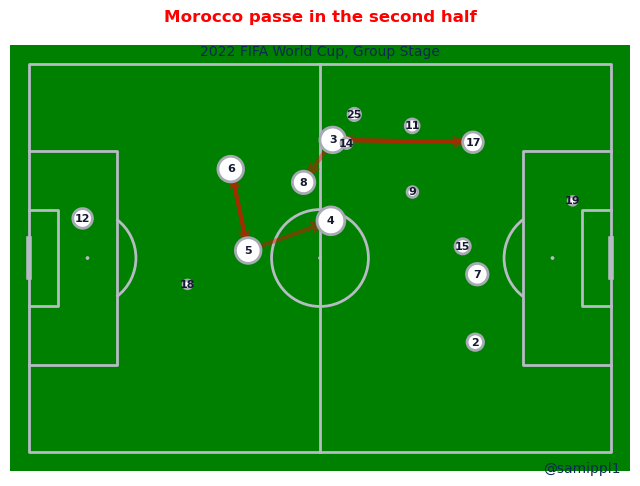

In [36]:
pitch = Pitch(pitch_color='green', line_color='#B6BBC4')
# Set the figure size
fig, ax = pitch.draw(figsize=(8, 6), constrained_layout=True, tight_layout=False)

# Set the face color of the figure
fig.set_facecolor('#FFFFFF')

# Draw arrows and nodes
arrows = pitch.arrows(1.2 * pass_between.x, 0.8 * pass_between.y, 1.2 * pass_between.x_end, 0.8 * pass_between.y_end, ax=ax,color='red', alpha=0.4,width=3)
# arrows = pass_between.apply(create_arrow, axis=1)
# for arrow in arrows:
#     ax.add_patch(arrow)
                 
nodes = pitch.scatter(1.2 * average_locations.x, 0.8 * average_locations.y, s=20*average_locations['count'].values, color='white', edgecolors='#a6aab3', linewidth=2, alpha=1, zorder=1, ax=ax)

                 
# Annotate average_locations
for index, row in average_locations.iterrows():
    pitch.annotate(index, xy=(1.2 * row.x, 0.8 * row.y), c='#161A30',fontweight='bold', va='center', ha='center', size=8, ax=ax)

# Add the endnote
ax.text(114, 85, '@samippl1', color='#0E2954', va='bottom', ha='center', fontsize=10)

# Add the title
ax.set_title('Morocco passe in the second half', color='red', va='center', ha='center', fontsize=12,fontweight='bold',pad=20,loc='center')
ax.annotate('2022 FIFA World Cup, Group Stage', xy=(0.5, 1), xytext=(0, 0),
             xycoords='axes fraction', textcoords='offset points',
             fontsize=10, color='#0E2954', va='top', ha='center')


plt.show()